---
bibliography:
  - bibliography.bib
---

# ARIMA Models

## Repetition

#### Autoregressive Models (AR)

We repeat the concept of autoregressive processes of order p (AR(p)-processes). Intuitively, the value of an AR(p) process at time $n$ is a *linear combination* of the $p$ previous values in the series. To be more precise

$$
X_n = a_1 X_{n-1} + a_2 X_{n-2} + \dots + a_{n-p} X_{n-p} + W_n
$$

$W_1, W_2, \dots $ is a white noise model with standard deviation $\sigma$. We now will generate an AR(2) Model. Let us consider the  AR(2) process

$$
X_{n} =1.5 X_{n-1} - 0.9 X_{n-2} + W_n
$$

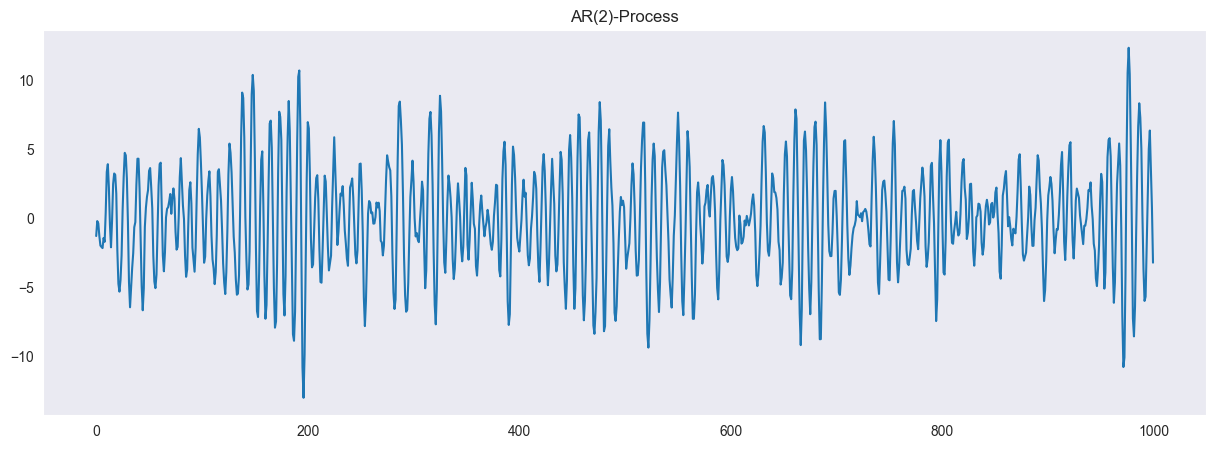

In [7]:
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib.pyplot as plt
import numpy as np

ar2 = [1, -1.5, 0.9]
model = ArmaProcess(ar = ar2, ma = None)
simulated_data = model.generate_sample(nsample=1000)

plt.figure(figsize = (15,5))
plt.plot(simulated_data, '-')
plt.grid()
plt.title("AR(2)-Process")
plt.show()

The characteristic polynomial is given by 
$$
\Phi(z) = 1 - a_1 z - a_2 z^2 - \dots - a_p z^p
$$
If all roots of $\Phi(z)$ have an absolute value larger than $1$, then the process is stationary. This can easily be checked with the `model.isstationary` command:

In [2]:
model.isstationary

True

We can even compute the complex roots of the polynomial, which are according to the lecture
$$
z_{1,2} = \frac{5}{6} \pm \frac{i}{2}\sqrt{\frac{5}{3}}
$$

In [4]:
model.arroots
np.abs(model.arroots)

array([1.05409255, 1.05409255])

Additionally, we compute the autocorrelation and partial autocorrelation both of the generated data (empirical autocorrelation (acf) / partial autocorrelation (pacf)) and for the process (theoretical). As we expect, the acf is oscillating and the pacf is vanishing after lags larger than $p$.

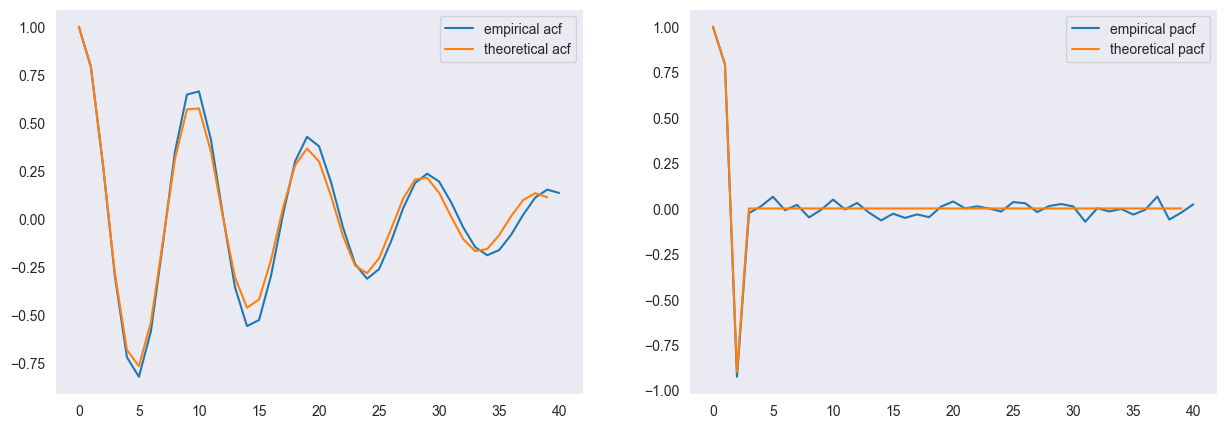

In [6]:
from statsmodels.tsa.stattools import acf, pacf

fig, ax = plt.subplots(1,2, figsize = (15,5))
ax[0].plot(acf(simulated_data, nlags=40), label = "empirical acf")
ax[0].plot(model.acf(lags=40), label = "theoretical acf")
ax[0].legend()
ax[0].grid()

ax[1].plot(pacf(simulated_data, nlags=40), label = "empirical pacf")
ax[1].plot(model.pacf(lags=40), label = "theoretical pacf")
ax[1].legend()
ax[1].grid()

#### Moving Average Model (MA)

Moving average models can be used to model dependencies in the noise of a stochastic process. A moving average model of order $q$ (MA(q)-process) is defined as

$$
X_n = W_n + b_1 W_{n-1} + \dots + b_q W_{n-q}
$$

$W_1, W_2, \dots $ is a white noise model with standard deviation $\sigma$. We now will generate an MA(4) Model. We consider the MA(4) process

$$
X_n = W_n + 1.5 W_{n-1} + 1.1 W_{n-2} + W_{n-3} + 0.9 W_{n-4}
$$

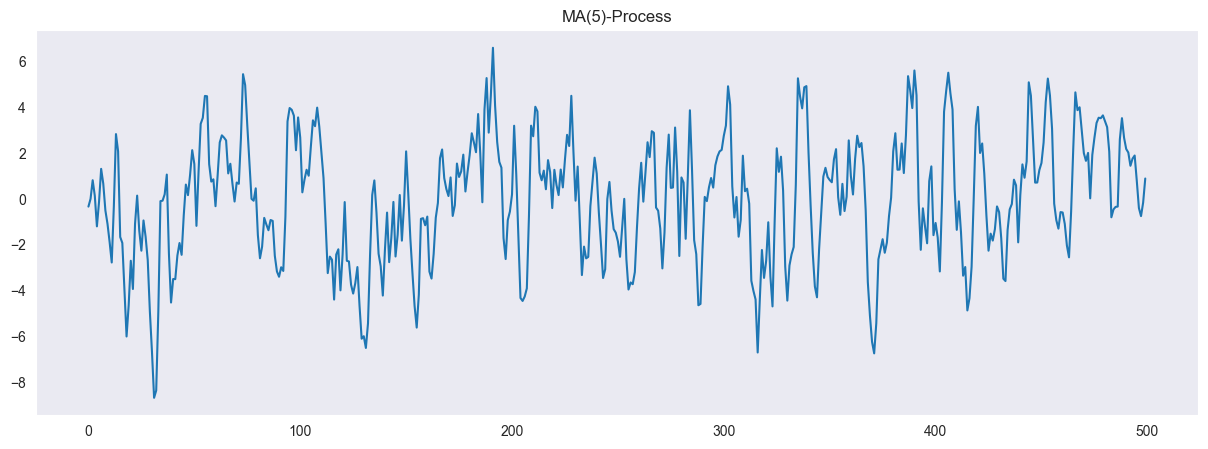

In [8]:
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib.pyplot as plt

ma4 = [1, 1.5, 1.1, 1, 0.9]
model = ArmaProcess(ar = None, ma = ma4)

simulated_data = model.generate_sample(nsample=500)

plt.figure(figsize = (15,5))
plt.plot(simulated_data, '-')
plt.grid()
plt.title("MA(5)-Process")
plt.show()

Moving average processes are always stationary but they are not unique in the sense that two different MA(q) processes can have the same autocorrelation function. Yet, there is always a unique process that is *invertible*. To check if a MA(q)-process is invertible we can investigate the roots of its characteristic polynomial

$$
\Theta(z) = 1 + b_1 z + b_2 z^2 + \dots + b_q z^q
$$

If all roots of $\Theta$ have absolute value larger than $1$, then the process is invertible. 

We check this for our process using the `model.isinvertible` command:

In [10]:
model.isinvertible

False

In [11]:
import numpy as np
np.abs(model.maroots)

array([0.92900679, 0.92900679, 1.13464461, 1.13464461])

We finally compute the autocorrelation and partial autocorrelation for our process (again, the empirical and the theoretical version). The acf of a MA(q) process vanishes for lags larger than $q$ and the pacf oscillates.

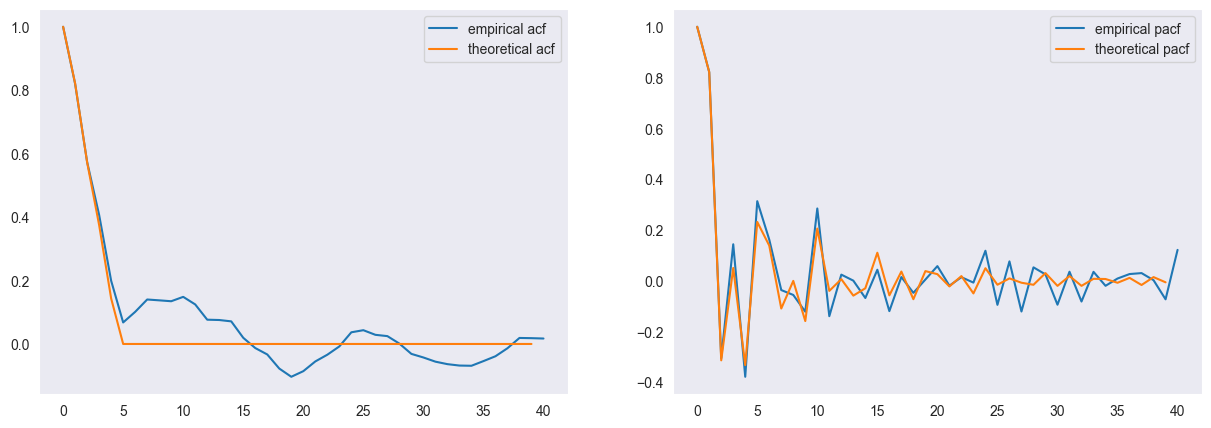

In [12]:
from statsmodels.tsa.stattools import acf, pacf

fig, ax = plt.subplots(1,2, figsize = (15,5))
ax[0].plot(acf(simulated_data, nlags=40), label = "empirical acf")
ax[0].plot(model.acf(lags=40), label = "theoretical acf")
ax[0].legend()
ax[0].grid()

ax[1].plot(pacf(simulated_data, nlags=40), label = "empirical pacf")
ax[1].plot(model.pacf(lags=40), label = "theoretical pacf")
ax[1].legend()
ax[1].grid()

### ARMA Model: AR and MA

By combining autoregressive and moving average models we arrive at ARMA(p,q)-processes. They are formally defined as

$$
\Phi(B) X_n =  \Theta(B) W_n
$$

where $\Phi$ and $\Theta$ are the characteristic polynomials of the autoregressive and moving average model respectively and $B$ is the *backshift operator*, i.e.
$$
B(X_n) = X_{n-1}
$$

In particular, we have
$$
\Phi(B) X_n = X_n - a_1 X_{n-1} - \dots - a_{p} X_{n-p}
$$

and
$$
\Theta(B) W_n = W_n - b_1 W_{n-1} - \dots - b_{q} X_{n-q}
$$

In the following, we will generate an AR(2,2) process. We define the ARMA(2,2) process as

We define the ARMA(2,2) process as
$$
X_n = 1.5 X_{n-1} - 0.9 X_{n-2} + W_n + 1.5 W_{n-1} + 2.2 W_{n-2} 
$$

or

$$
(1 - 1.5 B + 0.9 B^2) X_n = (1 + 1.5 B + 2.2 B^2) W_n.
$$


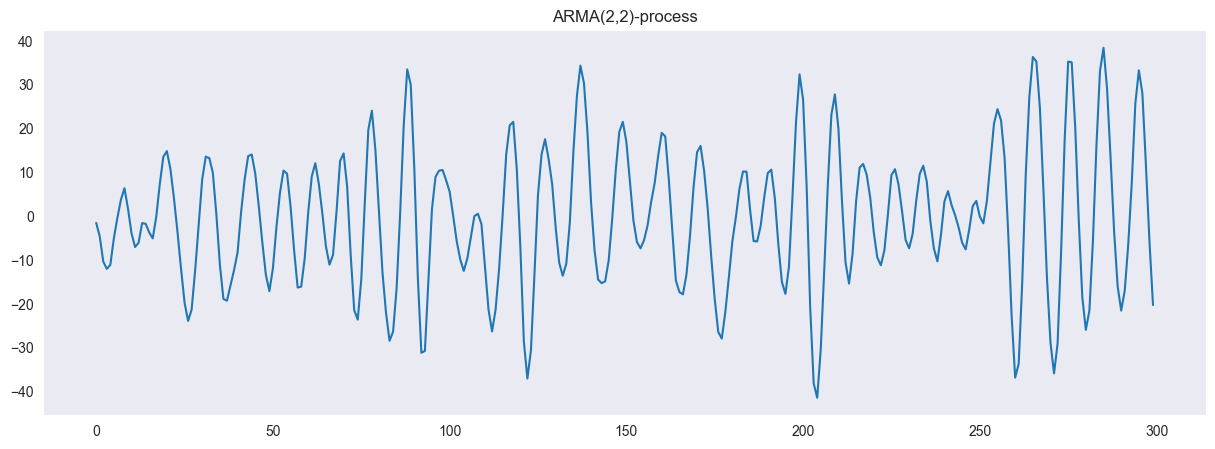

In [13]:
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib.pyplot as plt

ar2 = [1, -1.5, 0.9]
ma2 = [1, 1.5, 2.2]
model = ArmaProcess(ar = ar2, ma = ma2)
simulated_data = model.generate_sample(nsample=300)

plt.figure(figsize = (15,5))
plt.plot(simulated_data, '-')
plt.title("ARMA(2,2)-process")
plt.grid()
plt.show()

We can check the stationarity and causality of the model as with the pure AR(p) and MA(q) processes, i.w. via the roots of the repsective characteristic polynomials.

In [14]:
import numpy as np

print(model.isstationary)
print(np.abs(model.arroots))

True
[1.05409255 1.05409255]


In [15]:
import numpy as np

print(model.isinvertible)
print(np.abs(model.maroots))

False
[0.67419986 0.67419986]


The acf and pacf for an ARMA(p,q) model do not have any distinct cut-off behaviour that aids for model selection. We demonstrate this with the simulated data. 

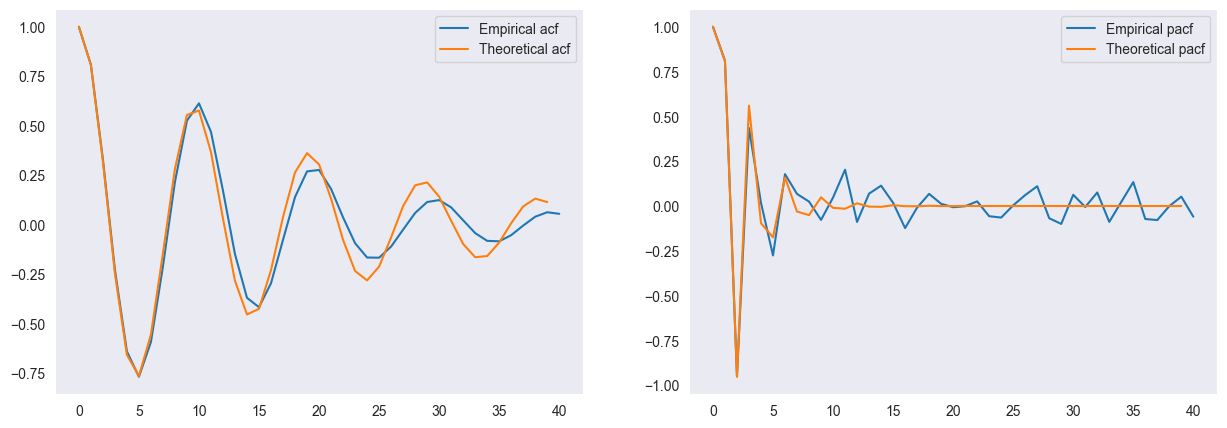

In [16]:
from statsmodels.tsa.stattools import acf, pacf

fig, ax = plt.subplots(1,2, figsize = (15,5))
ax[0].plot(acf(simulated_data, nlags=40), label = "Empirical acf")
ax[0].plot(model.acf(lags=40), label = "Theoretical acf")
ax[0].legend()
ax[0].grid()

ax[1].plot(pacf(simulated_data, nlags=40), label = "Empirical pacf")
ax[1].plot(model.pacf(lags=40), label = "Theoretical pacf")
ax[1].legend()
ax[1].grid()

#### Estimating ARMA(p,q) from data

We are now given a time series $x_1, x_2, \dots$ and we want to estimate for a given order $(p,q)$ the coefficients $a_1, \dots, a_p$ and $b_1, \dots, b_q$. We showed the maximum likelihood method as one approach (although there are different ways to estimate the coefficients)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("Time Series ARIMA Models/data/TeslaIdx1.csv", sep ="\t")
df.head()

We turn the data frame into a times series object

In [2]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', drop = True, inplace=True)
df.head()

,Close,Volume
Date,,
2012-10-19,27.74,1027302
2012-10-22,27.85,470198
2012-10-23,28.39,748998
2012-10-24,27.42,1016368
2012-10-25,27.52,577686


We compute the *log-returns* of the stock index for the closing value of the index, i.e.
$$
r^\text{log}_n = \log\left(\frac{X_{n}}{X_{n-1}}\right)
$$

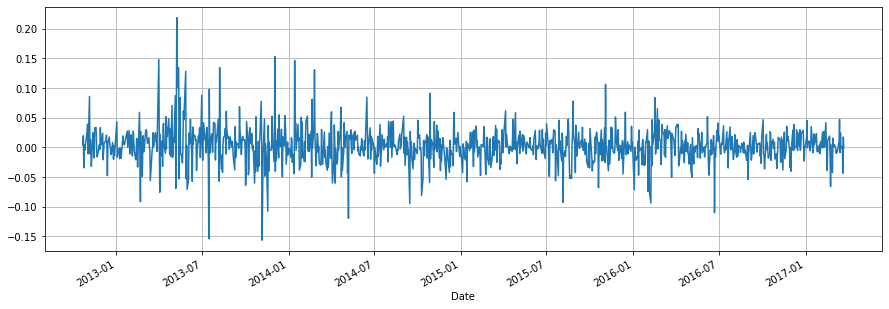

In [3]:
lr = np.log(df.Close.values[1:]/df.Close.values[:-1])
lr = np.r_[np.NaN, lr]
df['LogRet'] = lr
df['LogRet'].plot(figsize = (15,5))
plt.grid()

We use the `ARIMA` class to estimate the parameters. To this end, we initialize the class with the observed series and the order of the model. By calling `.fit()` the model parameters are estimated. The summary function gives a comprehensive report on the model.

In [4]:
df.dropna(axis = 0, inplace = True)
model = ARIMA(df.LogRet, order = (1,0,1))
res = model.fit()
print(res.summary())

/opt/conda/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:583: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
/opt/conda/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:583: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)
/opt/conda/lib/python3.7/site-packages/statsmodels/tsa/base/tsa_model.py:583: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  ' ignored when e.g. forecasting.', ValueWarning)


                               SARIMAX Results                                
Dep. Variable:                 LogRet   No. Observations:                 1111
Model:                 ARIMA(1, 0, 1)   Log Likelihood                2308.225
Date:                Wed, 13 Dec 2023   AIC                          -4608.449
Time:                        13:20:25   BIC                          -4588.397
Sample:                             0   HQIC                         -4600.867
                               - 1111                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0020      0.001      2.111      0.035       0.000       0.004
ar.L1         -0.2060      0.864     -0.238      0.812      -1.899       1.487
ma.L1          0.2277      0.864      0.263      0.7

The summary shows that the estimated coefficients are not significantly different from $0$ which means, that the time series can not be modelled by means of an AR(1,1) model. This is also the reason why you whitness different coefficients compared to the slides: Since there is no *real* model describing the log-returns of the Tesla stock index the estimated coefficients are just due to some numerical algorithm. Depending on the algorithm implementation you will receive other results. 

The plot below showing the predicted values further stresses the fact that modelling of the log-returns is futile.

<AxesSubplot:xlabel='Date'>

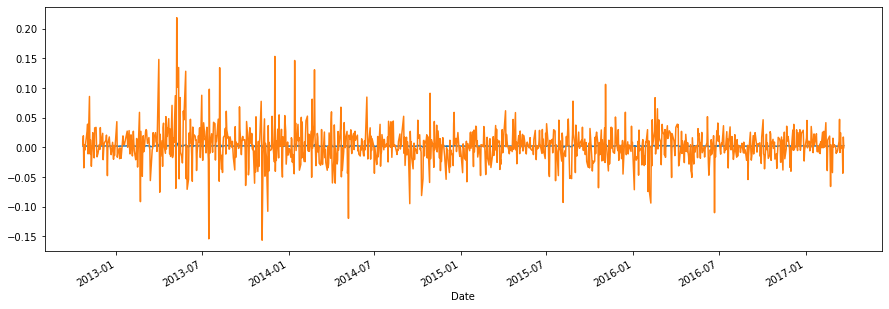

In [5]:
plt.figure(figsize = (15,5))
plt.plot(res.predict())
df.LogRet.plot()

#### Model selection for ARMA(p,q)

So far we did not bother about choosing the model order. However, this is a delicate task since the acf and pacf plots no longer help in this respect. Instead we will focus on the Akaike information criterion (AIC) as a goodness-of-fit measure that is comparable across various model dimensions. It is defined as

$$
AIC(p,q) = -2\cdot \log(L(\vec \theta, \vec x )) + 2(p + q + 1)
$$

Here $L$ is the likelihood function of the problem and $\vec\theta$ the vector of all unknown parameters in the model. The vector $\vec x$ contains the time series data that we want to model. For a fitted model - let us choose arbitrarily the model ARIMA(2,1,2) - the AIC value can be retrieved. 

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Time Series ARIMA Models/data/temperatures.csv")
df['Year'] = pd.to_datetime(df['Year'], format="%Y")
df.set_index('Year', drop = True, inplace=True)
df.dropna(axis = 0, inplace = True)
model = ARIMA(df.Value, order = (2,1,2))
res = model.fit()
print(res.aic)

The model predictions look as follows:

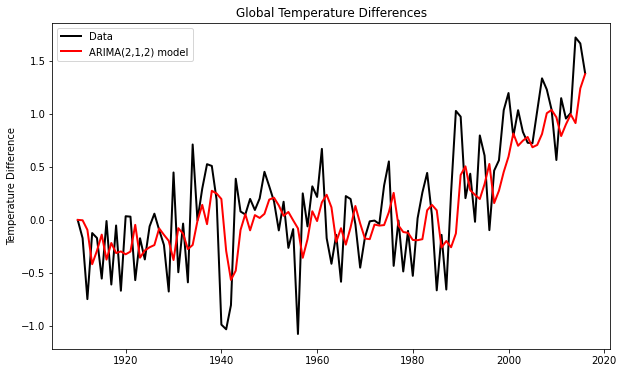

In [2]:
# Plot the original data

temp = df['Value']
plt.figure(figsize=(10, 6))
plt.plot(temp, label='Data', color='black', linewidth=2)
plt.plot(temp - res.resid, label='ARIMA(2,1,2) model', color='red', linewidth=2)
plt.title("Global Temperature Differences")
plt.ylabel("Temperature Difference")
plt.legend()
plt.show()

How do we determine the differencing order $d$ and the order parameters $p$ for the AR(p) process and $q$ for the MA(q) process?

##### STEP 1 : Determine the Differencing Order d

We start with order $d=1$, i.e., we compute the differences of the temperatures

$$
Y_n = X_{n} - X_{n-1} = (1 - B) X_n
$$

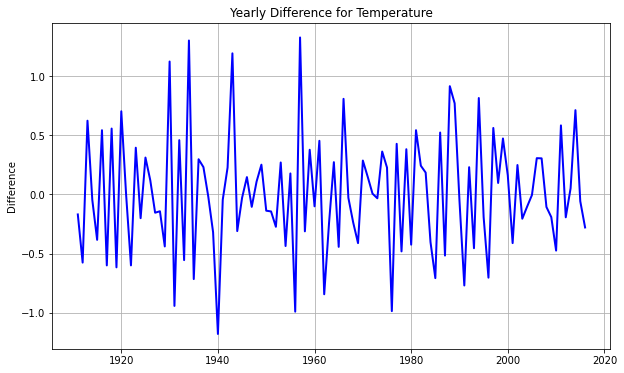

In [3]:
# Extract the temperature column
temp = df['Value']

# Plot the first order difference
plt.figure(figsize=(10, 6))
plt.plot(temp.diff(), label='Yearly Difference', color='blue', linewidth=2)
plt.title("Yearly Difference for Temperature")
plt.ylabel("Difference")
plt.grid(True)
plt.show()


The trend is not any more visible. Thus, we choose $d=1$ as differencing order.

##### STEP 2 : Determine the Order Parameters p and q

We now simply loop over a range of candidate model and select the best model in terms of the lowest AIC value. This is a brute force method that is limited by the amount of candidate model that we consider.

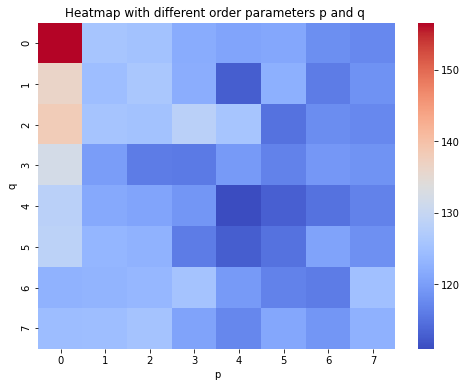

In [4]:
from itertools import product
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

ar = np.arange(8)
ma = np.arange(8)

AIC = np.zeros((8,8))
for comb in product(ar, ma):
    p = comb[0]
    q = comb[1]
    model = ARIMA(temp, order = (p,1,q))
    res = model.fit()
    AIC[p,q] = res.aic

plt.figure(figsize=(8, 6))
ax = sns.heatmap(AIC, cmap='coolwarm')


# Labeling
ax.set_xlabel('p')
ax.set_ylabel('q')
ax.set_title('Heatmap with different order parameters p and q ')
plt.show()

On the basis of the heatmap, we choose $p=4$ and $q=4$ which shows the lowest AIC value.

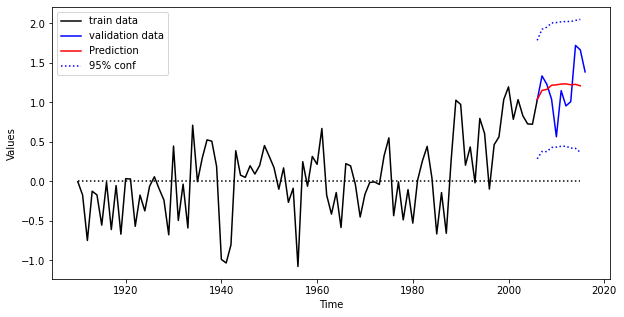

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA



# Fit the ARIMA model
model_opt = ARIMA(temp["1910":"2006"], order=(4, 1, 4)).fit()

# Predict including confidence interval
pred = model_opt.get_prediction(start="2007", end="2016")
pred = pred.prediction_results
pred_cov = pred._forecasts_error_cov
pred = pred._forecasts[0]
pred_upper = pred + 1.96 * np.sqrt(pred_cov[0][0])
pred_lower = pred - 1.96 * np.sqrt(pred_cov[0][0])

# Plot
x = temp.index.year
x_pred = np.arange(2006, 2016)
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(x[:97], temp["1910":"2006"], '-k', label='train data')
ax.plot(x[96:], temp["2006":"2016"], 'b', label='validation data')
ax.plot(x_pred, pred, 'r', label='Prediction')
ax.plot(x_pred, pred_upper, ':b', label='95% conf')
ax.plot(x_pred, pred_lower, ':b')
ax.plot([x[0], x_pred[-1]], [0, 0], ':k')
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.show()


### Performance Metrics

#### MAE

In [ ]:
# Actual values for the prediction period
observed_values = temp["2007":"2016"]
pred = model_opt.get_prediction(start="2007", end="2016")
pred = pred.prediction_results
predicted_values = pred._forecasts[0]

# Calculating MAE
mae = np.mean(np.abs(predicted_values - observed_values))
print("Mean Absolute Error (MAE):", mae)

#### RMSE

In [ ]:
# Calculating RMSE
rmse = np.sqrt(np.mean((predicted_values - observed_values) ** 2))
print("Root Mean Square Error (RMSE):", rmse)

#### MAPE

In [ ]:
# Calculating MAPE
mape = np.mean(np.abs((observed_values - predicted_values) / observed_values)) * 100
print("Mean Absolute Percentage Error (MAPE):", mape, "%")

#### Quartile Score

In [ ]:
import scipy.stats as stats

# Forecast
forecast_length = len(predicted_values)
forecast_result = model_opt.get_forecast(steps=forecast_length)
forecast_mean = forecast_result.predicted_mean
forecast_std = np.sqrt(forecast_result.var_pred_mean)

# Function to compute quantile forecasts
def compute_quantile_forecasts(mean, std, quantiles):
    forecasts = {}
    for quantile in quantiles:
        z_score = stats.norm.ppf(quantile)
        forecasts[quantile] = mean + z_score * std
    return forecasts

# Quantiles to compute
quantiles = [0.25, 0.5, 0.75]

# Compute quantile forecasts
quantile_forecasts = compute_quantile_forecasts(forecast_mean, forecast_std, quantiles)

# Function to calculate pinball loss
def pinball_loss(y_true, y_pred, quantile):
    delta = y_true - y_pred
    return np.mean(np.where(delta >= 0, quantile * delta, (quantile - 1) * delta))

# Calculate quartile scores for each quantile forecast
quartile_scores = {}
for quantile in quantiles:
    quartile_scores[quantile] = pinball_loss(observed_values, quantile_forecasts[quantile], quantile)

# Display the quartile scores
for quantile, score in quartile_scores.items():
    print(f"Quartile score for quantile {quantile}: {score}")